# Real-time REM detection on the Walch (2019) data

A walk-through of the pipeline on the dataset, using the project modules
(`dataset`, `features`, `module`, `splits`, `evaluate`):

1. the raw wearable signals and PSG labels,
2. the causal features,
3. the real-time (look-ahead) check,
4. leave-one-subject-out evaluation,
5. multiclass sleep staging with a REM-focused score.

Feature extraction lives in `features.py`; `module.py` holds the model.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

import features, splits
from dataset import load_records, REM
from module import build_model

records = load_records()
n_scored = sum(int(r.scored_mask.sum()) for r in records)
n_rem = sum(int((r.stage == REM).sum()) for r in records)
print(f"{len(records)} subjects | {n_scored} scored 30s epochs | "
      f"REM prevalence {100 * n_rem / n_scored:.1f}%")

def rem_spans(r):
    '''Contiguous REM intervals (in hours) for shading plots.'''
    flag = (r.stage == REM).astype(int)
    d = np.diff(flag, prepend=0, append=0)
    starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
    h = r.epoch_time / 3600
    return [(h[s], h[min(e, len(h) - 1)]) for s, e in zip(starts, ends)]

['/Users/mustaf/Desktop/realtime-rem-detection/data/4426783_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/5498603_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/1455390_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/7749105_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/8692923_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/8258170_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/1360686_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/781756_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/8686948_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/759667_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/2598705_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/9618981_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-rem-detection/data/99

31 subjects | 26773 scored 30s epochs | REM prevalence 22.0%


## 1. The data

Each subject is one night: heart rate (~0.2 Hz) and triaxial accelerometer
(~30 Hz) from an Apple Watch, with a polysomnography hypnogram at 30 s resolution.
One subject's raw streams, REM periods shaded.

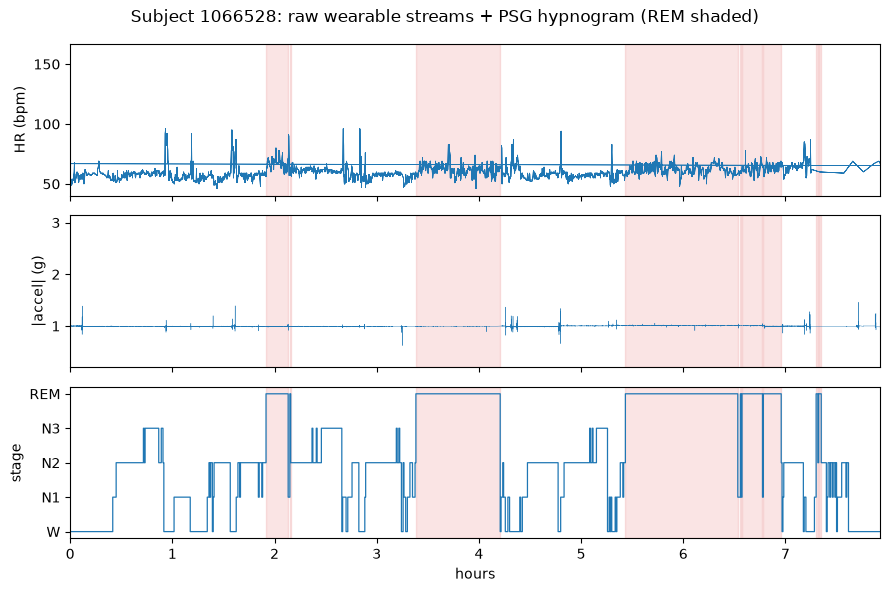

In [2]:
r = records[0]
mag = np.linalg.norm(r.motion, axis=1)
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
ax[0].plot(r.hr_time / 3600, r.hr, lw=0.5); ax[0].set_ylabel("HR (bpm)")
ax[0].set_xlim(0, r.epoch_time.max() / 3600)
ax[1].plot(r.motion_time[::50] / 3600, mag[::50], lw=0.3); ax[1].set_ylabel("|accel| (g)")
ax[2].step(r.epoch_time / 3600, r.stage, where="post", lw=0.9)
ax[2].set_yticks([0, 1, 2, 3, 4]); ax[2].set_yticklabels(["W", "N1", "N2", "N3", "REM"])
ax[2].set_ylabel("stage"); ax[2].set_xlabel("hours")
for a in ax:
    for s, e in rem_spans(r): a.axvspan(s, e, color="tab:red", alpha=0.12)
fig.suptitle(f"Subject {r.subject_id}: raw wearable streams + PSG hypnogram (REM shaded)")
plt.tight_layout(); plt.show()

## 2. Features

`features.featurize` turns the raw streams into one row per epoch. The first three
columns are the paper's base features -- smoothed heart rate, ActiGraph activity
counts (via `agcounts`), and time-of-night -- and the rest are causal *temporal*
features over HR and activity: the rate of change, and rolling means / standard
deviations over ~5 and ~15 min windows (REM shows elevated, variable HR with
near-still motion). Every column uses only samples at or before the end of its
epoch. The column order and each feature's on-device state are documented in
`features.FEATURE_NAMES` and the deployment-state contract at the top of
`features.py`.

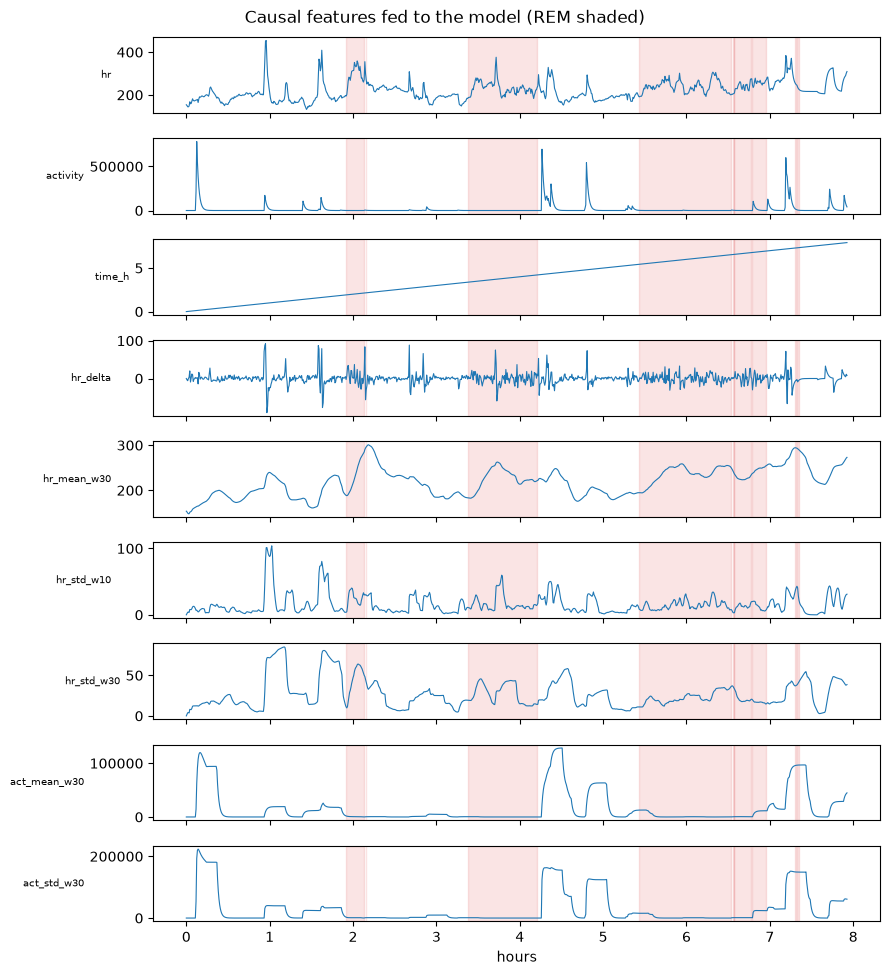

feature matrix shape (epochs x features): (952, 9)
columns: ['hr', 'activity', 'time_h', 'hr_delta', 'hr_mean_w30', 'hr_std_w10', 'hr_std_w30', 'act_mean_w30', 'act_std_w30']


In [3]:
X_one = features.featurize(r)
names = features.FEATURE_NAMES
fig, ax = plt.subplots(len(names), 1, figsize=(9, 1.1 * len(names)), sharex=True)
for k, name in enumerate(names):
    ax[k].plot(r.epoch_time / 3600, X_one[:, k], lw=0.8)
    ax[k].set_ylabel(name, fontsize=7, rotation=0, ha="right", va="center")
    for s, e in rem_spans(r): ax[k].axvspan(s, e, color="tab:red", alpha=0.12)
ax[-1].set_xlabel("hours")
fig.suptitle("Causal features fed to the model (REM shaded)")
plt.tight_layout(); plt.show()
print(f"feature matrix shape (epochs x features): {X_one.shape}")
print("columns:", names)

## 3. Real-time (look-ahead) check

A live watch scores each epoch using only data up to that moment. `evaluate.py`
checks this every fold with `_predictions_are_causal`: at several cut points the
first-k predictions must be unchanged when later epochs are removed and when their
content is altered. Below, a causal model passes and a model that reads one epoch
ahead does not.

In [4]:
from evaluate import _predictions_are_causal

X, y, groups = splits.make_dataset(records)     # fixed causal features for every epoch
train_idx, test_idx = next(splits.cross_validator().split(X, y, groups=groups))
model = build_model().fit(X[train_idx], y[train_idx])
X_test = X[test_idx]
print("real-time (causal) model passes the guard :",
      _predictions_are_causal(model, X_test, model.predict(X_test)))

class LookAheadModel:               # cheats: labels epoch i using epoch i+1
    def predict(self, Xa):
        nxt = np.r_[Xa[1:, 0], Xa[-1, 0]]
        return (nxt > 0.5).astype(int)

cheat = LookAheadModel()
print("look-ahead (cheating) model passes the guard:",
      _predictions_are_causal(cheat, X_test, cheat.predict(X_test)))

/Users/mustaf/Desktop/realtime-rem-detection/.venv/lib/python3.12/site-packages/agcounts/extract.py:347: RuntimeWarning: invalid value encountered in cast
  return counts.astype(int)


real-time (causal) model passes the guard : True
look-ahead (cheating) model passes the guard: False


## 4. Leave-one-subject-out

Epochs from one sleeper are correlated, so testing on a subject you trained on
inflates the score. `splits` groups epochs by subject and uses scikit-learn's
`LeaveOneGroupOut`: each subject is the test set once and never appears in its own
training fold.

In [5]:
cv = splits.cross_validator()
n_folds = cv.get_n_splits(groups=groups)
disjoint = all(set(groups[tr]).isdisjoint(set(groups[te])) for tr, te in cv.split(X, y, groups=groups))
print(f"{n_folds} folds | every subject held out once | train/test subject-disjoint: {disjoint}")
print(f"feature matrix: {X.shape[0]} epochs x {X.shape[1]} fixed features")

31 folds | every subject held out once | train/test subject-disjoint: True
feature matrix: 26773 epochs x 9 fixed features


## 5. Multiclass sleep staging (REM-focused)

The model now classifies each epoch into all five stages (Wake, N1, N2, N3, REM)
instead of REM vs not-REM -- the idea being that letting it tell the non-REM stages
apart should sharpen the REM boundary rather than lumping everything else into one
blob. We report **REM one-vs-rest** (the F-beta(0.3) Weco maximizes, plus precision
and recall) and, below it, the full **per-class breakdown and 5-class confusion** so
you can see how the other stages fare. This uses `build_model()` from `module.py`,
so it is exactly the estimator the harness scores.

REM one-vs-rest: F-beta(0.3) = 0.4276 +/- 0.0208 SEM | precision 0.416  recall 0.720  (per-subject mean over 30 folds)

overall, pooled over all epochs (all five stages):
              precision    recall  f1-score   support

        Wake       0.68      0.38      0.49      2429
          N1       0.21      0.01      0.01      1821
          N2       0.60      0.57      0.58     12954
          N3       0.53      0.40      0.45      3685
         REM       0.41      0.73      0.52      5884

    accuracy                           0.52     26773
   macro avg       0.49      0.42      0.41     26773
weighted avg       0.53      0.52      0.51     26773



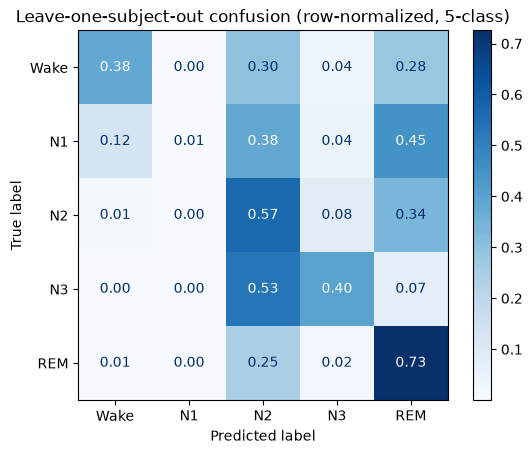

In [6]:
from sklearn.metrics import (fbeta_score, precision_score, recall_score,
                             classification_report, ConfusionMatrixDisplay)
from dataset import WAKE, N1, N2, N3

BETA = 0.3
STAGES = [WAKE, N1, N2, N3, REM]
LABELS = ["Wake", "N1", "N2", "N3", "REM"]

fb, pr, rc, yt_all, yp_all = [], [], [], [], []
for tr, te in splits.cross_validator().split(X, y, groups=groups):
    m = build_model().fit(X[tr], y[tr])                    # module.py's multiclass model
    yp, yt = m.predict(X[te]), y[te]
    yt_all.append(yt); yp_all.append(yp)
    if (yt == REM).sum() == 0:                             # no REM -> REM metrics undefined
        continue
    fb.append(fbeta_score(yt, yp, beta=BETA, labels=[REM], average="macro", zero_division=0))
    pr.append(precision_score(yt, yp, labels=[REM], average="macro", zero_division=0))
    rc.append(recall_score(yt, yp, labels=[REM], average="macro", zero_division=0))

fb = np.array(fb)
print(f"REM one-vs-rest: F-beta(0.3) = {fb.mean():.4f} +/- {fb.std(ddof=1)/np.sqrt(fb.size):.4f} SEM "
      f"| precision {np.mean(pr):.3f}  recall {np.mean(rc):.3f}  (per-subject mean over {fb.size} folds)")

yt_all, yp_all = np.concatenate(yt_all), np.concatenate(yp_all)
print("\noverall, pooled over all epochs (all five stages):")
print(classification_report(yt_all, yp_all, labels=STAGES, target_names=LABELS, zero_division=0))
ConfusionMatrixDisplay.from_predictions(yt_all, yp_all, labels=STAGES, display_labels=LABELS,
                                        normalize="true", cmap="Blues", values_format=".2f")
plt.title("Leave-one-subject-out confusion (row-normalized, 5-class)"); plt.show()

## Summary

The pipeline runs end to end: wearable and PSG signals, the fixed causal features, a
look-ahead check, and a per-subject leave-one-subject-out score. The task is now
five-class sleep staging, but the reported metric stays **REM F-beta(0.3)** (REM
one-vs-rest, precision-weighted) -- with a full per-class breakdown alongside it so
the other stages stay visible. `weco run` rewrites the model in `module.py` (the
features in `features.py` stay fixed) to raise the REM score, and the look-ahead
check keeps every candidate deployable in real time.